# Show Bronze — Análise de Vendas (SQL)
pip install duckdb jupysql duckdb-engine pandas matplotlib



## 0. Configuração

Carrega a extensão SQL do Jupyter (`jupysql`), conecta ao DuckDB, e cria uma **view** para cada CSV — a partir daqui, cada tabela pode ser consultada com SQL puro, como se fosse um banco de dados de verdade.

In [1]:
%load_ext sql
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

conn = duckdb.connect()
%sql conn --alias duckdb
%config SqlMagic.displaylimit = 20

CAMINHO = 'dados/'


In [2]:
%%sql
CREATE OR REPLACE VIEW dim_categoria   AS SELECT * FROM read_csv_auto('dados/dim_categoria.csv');
CREATE OR REPLACE VIEW dim_marca       AS SELECT * FROM read_csv_auto('dados/dim_marca.csv');
CREATE OR REPLACE VIEW dim_loja        AS SELECT * FROM read_csv_auto('dados/dim_loja.csv');
CREATE OR REPLACE VIEW dim_faixa_preco AS SELECT * FROM read_csv_auto('dados/dim_faixa_preco.csv');
CREATE OR REPLACE VIEW dim_produto     AS SELECT * FROM read_csv_auto('dados/dim_produto.csv');
CREATE OR REPLACE VIEW dim_data        AS SELECT * FROM read_csv_auto('dados/dim_data.csv');
CREATE OR REPLACE VIEW fato_vendas     AS SELECT * FROM read_csv_auto('dados/fato_vendas.csv');


Running query in 'duckdb'

Count


In [3]:
%%sql
SELECT table_name, estimated_size AS linhas
FROM duckdb_tables()
ORDER BY table_name;

Running query in 'duckdb'

table_name,linhas


---
## 1. Visão Geral


### 1.1 KPIs principais

In [4]:
%%sql
SELECT
    SUM(valor_liquido)                                              AS faturamento_liquido,
    SUM(quantidade_vendida)                                          AS qtde_vendida,
    ROUND(SUM(valor_liquido) / COUNT(*), 2)                           AS ticket_medio,
    ROUND(SUM(valor_desconto) / NULLIF(SUM(valor_bruto), 0) * 100, 2)  AS pct_desconto_medio
FROM fato_vendas;

Running query in 'duckdb'

faturamento_liquido,qtde_vendida,ticket_medio,pct_desconto_medio
4082325.2799999975,139368,1316.88,7.4


### 1.2 Faturamento Líquido por Mês, com comparação ano anterior (LY / YoY)

In [5]:
%%sql
WITH mensal AS (
    SELECT
        d.ano, d.mes,
        SUM(f.valor_liquido) AS faturamento_liquido
    FROM fato_vendas f
    JOIN dim_data d ON f.id_data = d.id_data
    GROUP BY d.ano, d.mes
)
SELECT
    ano, mes, faturamento_liquido,
    LAG(faturamento_liquido) OVER (PARTITION BY mes ORDER BY ano) AS faturamento_liquido_ly,
    ROUND(
        100.0 * (faturamento_liquido - LAG(faturamento_liquido) OVER (PARTITION BY mes ORDER BY ano))
        / NULLIF(LAG(faturamento_liquido) OVER (PARTITION BY mes ORDER BY ano), 0)
    , 2) AS pct_yoy
FROM mensal
ORDER BY ano, mes;

Running query in 'duckdb'

ano,mes,faturamento_liquido,faturamento_liquido_ly,pct_yoy
2016,9,636.0,None,None
2016,10,6395.12,None,None
2016,11,6843.33,None,None
2016,12,15061.630000000001,None,None
2017,1,10867.09,None,None
2017,2,16737.18,None,None
2017,3,15407.600000000002,None,None
2017,4,21372.050000000003,None,None
2017,5,28723.730000000003,None,None
2017,6,32287.120000000006,None,None


Guarda o resultado da última query numa variável Python (`_.DataFrame()`, recurso do jupysql) só pra poder desenhar o gráfico — o cálculo em si já foi feito 100% em SQL acima.

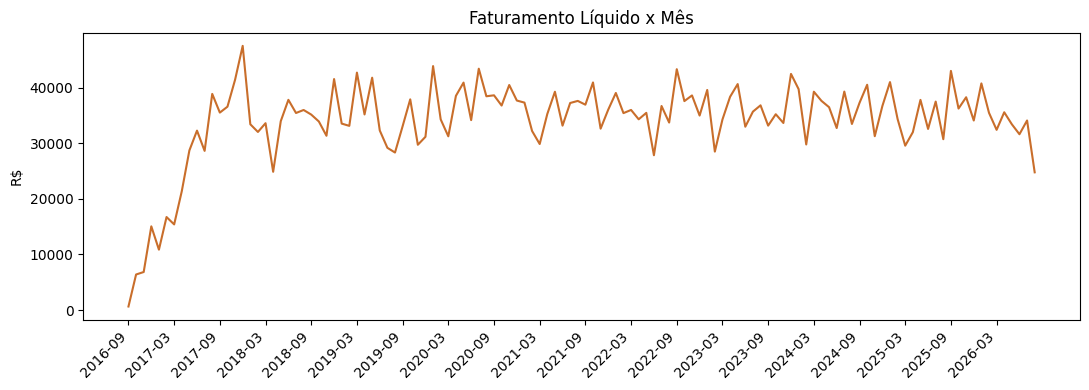

In [6]:
mensal_df = _.DataFrame()
mensal_df['ano_mes'] = mensal_df['ano'].astype(str) + '-' + mensal_df['mes'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(mensal_df['ano_mes'], mensal_df['faturamento_liquido'], color='#C96E2B')
ax.set_xticks(mensal_df['ano_mes'][::6])
ax.set_xticklabels(mensal_df['ano_mes'][::6], rotation=45, ha='right')
ax.set_title('Faturamento Líquido x Mês')
ax.set_ylabel('R$')
plt.tight_layout()
plt.show()


### 1.3 Eficácia do desconto — a política de desconto aumenta o volume médio por venda?

In [7]:
%%sql
SELECT
    desconto_percentual,
    COUNT(*)                          AS qtde_vendas,
    ROUND(AVG(quantidade_vendida), 1) AS qtde_media_por_venda
FROM fato_vendas
GROUP BY desconto_percentual
ORDER BY desconto_percentual;

Running query in 'duckdb'

desconto_percentual,qtde_vendas,qtde_media_por_venda
0,1319,44.4
5,432,43.8
10,440,46.5
15,474,46.1
20,435,45.1


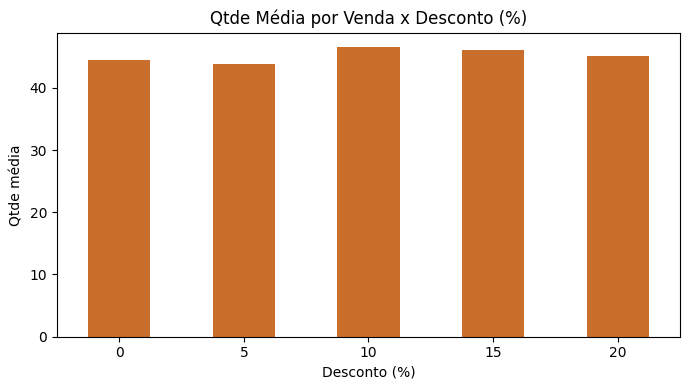

In [8]:
eficacia_df = _.DataFrame()
eficacia_df.plot(x='desconto_percentual', y='qtde_media_por_venda', kind='bar',
                  title='Qtde Média por Venda x Desconto (%)', color='#C96E2B', legend=False, figsize=(7, 4))
plt.ylabel('Qtde média')
plt.xlabel('Desconto (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 1.4 Top 5 Produtos por Faturamento Líquido

In [9]:
%%sql
SELECT
    p.nome_produto,
    SUM(f.valor_liquido) AS faturamento_liquido
FROM fato_vendas f
JOIN dim_produto p ON f.id_produto = p.id_produto
GROUP BY p.nome_produto
ORDER BY faturamento_liquido DESC
LIMIT 5;

Running query in 'duckdb'

nome_produto,faturamento_liquido
ÓLEO ILUMINADOR AMENDOAS E JOJOBA 100ML,284771.7899999999
PROTETOR SOLAR FPS 30 CAPILAR ESSENCIA 200g,268651.58
ATIVADOR DE BRONZEADO NICOLE BAHLS 100g,206015.46
CAIXA BANHO DE LUA HOME CARE,185122.81999999995
ÓLEO BRONZEADOR COCO E URUCUM - 100ml,185055.51000000007


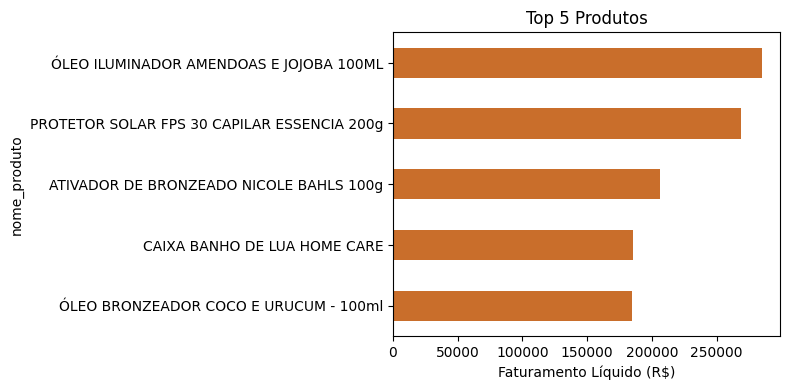

In [10]:
top5_df = _.DataFrame().sort_values('faturamento_liquido')
top5_df.plot(x='nome_produto', y='faturamento_liquido', kind='barh',
             title='Top 5 Produtos', color='#C96E2B', legend=False, figsize=(8, 4))
plt.xlabel('Faturamento Líquido (R$)')
plt.tight_layout()
plt.show()


---
## 2. Canais e Descontos


### 2.1 Faturamento por Loja

In [11]:
%%sql
SELECT
    l.nome_loja,
    SUM(f.valor_liquido) AS faturamento_liquido
FROM fato_vendas f
JOIN dim_loja l ON f.id_loja = l.id_loja
GROUP BY l.nome_loja
ORDER BY faturamento_liquido DESC;

Running query in 'duckdb'

nome_loja,faturamento_liquido
Revendedor Armazém do Bronze,1085615.4799999988
Revendedor Cosmed Bronze,1010725.3300000001
Mercado Livre,1004010.4199999992
E-commerce Próprio,981974.0499999996


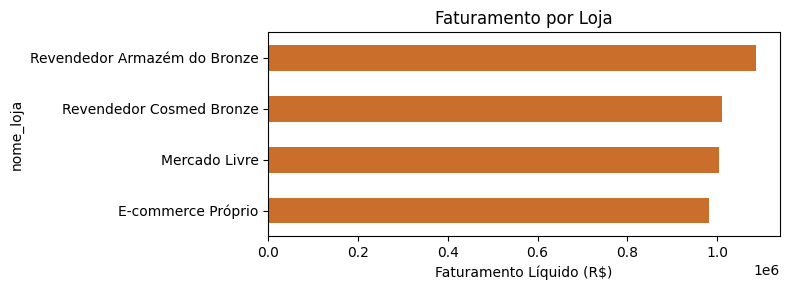

In [12]:
loja_df = _.DataFrame().sort_values('faturamento_liquido')
loja_df.plot(x='nome_loja', y='faturamento_liquido', kind='barh',
             title='Faturamento por Loja', color='#C96E2B', legend=False, figsize=(8, 3))
plt.xlabel('Faturamento Líquido (R$)')
plt.tight_layout()
plt.show()


### 2.2 Faturamento por Tipo de Canal (Direto x Marketplace x B2B)

In [13]:
%%sql
SELECT
    l.tipo_canal,
    SUM(f.valor_liquido)                                                       AS faturamento_liquido,
    ROUND(100.0 * SUM(f.valor_liquido) / SUM(SUM(f.valor_liquido)) OVER (), 2)  AS pct_participacao
FROM fato_vendas f
JOIN dim_loja l ON f.id_loja = l.id_loja
GROUP BY l.tipo_canal
ORDER BY faturamento_liquido DESC;

Running query in 'duckdb'

tipo_canal,faturamento_liquido,pct_participacao
B2B,2096340.809999997,51.35
Marketplace,1004010.4199999992,24.59
Direto,981974.0499999996,24.05


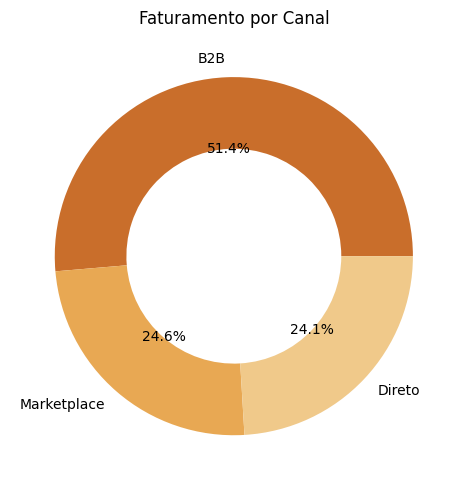

In [14]:
canal_df = _.DataFrame()
fig, ax = plt.subplots(figsize=(5, 5))
cores = ['#C96E2B', '#E8A853', '#F0C98A']
ax.pie(canal_df['faturamento_liquido'], labels=canal_df['tipo_canal'], autopct='%1.1f%%',
       colors=cores, wedgeprops=dict(width=0.4))
ax.set_title('Faturamento por Canal')
plt.tight_layout()
plt.show()


### 2.3 % Desconto Médio por Canal

In [15]:
%%sql
SELECT
    l.tipo_canal,
    ROUND(100.0 * SUM(f.valor_desconto) / NULLIF(SUM(f.valor_bruto), 0), 2) AS pct_desconto_medio
FROM fato_vendas f
JOIN dim_loja l ON f.id_loja = l.id_loja
GROUP BY l.tipo_canal
ORDER BY pct_desconto_medio DESC;

Running query in 'duckdb'

tipo_canal,pct_desconto_medio
Direto,7.56
B2B,7.48
Marketplace,7.09


### 2.4 Qtde de Lojas Ativas

In [16]:
%%sql
SELECT COUNT(DISTINCT id_loja) AS qtde_lojas_ativas
FROM fato_vendas;

Running query in 'duckdb'

qtde_lojas_ativas
4


---
## 3. Produto e Categoria


### 3.1 Faturamento por Categoria

In [17]:
%%sql
SELECT
    c.nome_categoria,
    SUM(f.valor_liquido) AS faturamento_liquido
FROM fato_vendas f
JOIN dim_categoria c ON f.id_categoria = c.id_categoria
GROUP BY c.nome_categoria
ORDER BY faturamento_liquido DESC;

Running query in 'duckdb'

nome_categoria,faturamento_liquido
PARAFINAS,858860.6100000012
ÓLEOS,703001.4100000004
KITS,437249.7099999999
ILUMINADORES,396362.7900000001
ESFOLIANTES,289009.26000000007
PÓS SOL,288052.9000000001
PROTEÇÃO SOLAR,268651.58
SABONETES,197762.9599999999
BANHO DE LUA,185122.81999999995
AUTOBRONZEADORES,163712.43


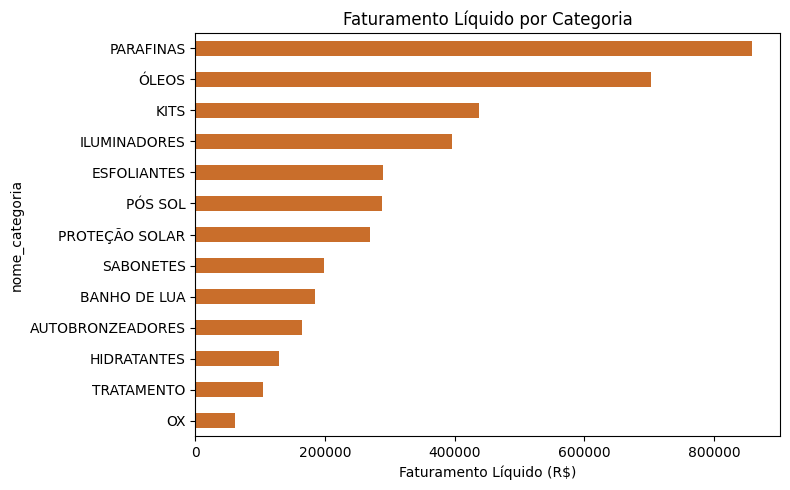

In [18]:
categoria_df = _.DataFrame().sort_values('faturamento_liquido')
categoria_df.plot(x='nome_categoria', y='faturamento_liquido', kind='barh',
                   title='Faturamento Líquido por Categoria', color='#C96E2B', legend=False, figsize=(8, 5))
plt.xlabel('Faturamento Líquido (R$)')
plt.tight_layout()
plt.show()


### 3.2 Matriz de Produtos — Ranking geral e % sobre o subtotal da categoria
A mesma lógica das medidas DAX `Ranking de Produtos` e `% sobre o Subtotal da Categoria` (com `ISINSCOPE`), resolvida aqui com `RANK() OVER` e `SUM() OVER (PARTITION BY...)` — window functions puras, sem pandas nenhum no cálculo.

In [19]:
%%sql
WITH produto_totais AS (
    SELECT
        c.nome_categoria,
        p.nome_produto,
        SUM(f.valor_liquido) AS faturamento_liquido
    FROM fato_vendas f
    JOIN dim_produto p   ON f.id_produto = p.id_produto
    JOIN dim_categoria c ON f.id_categoria = c.id_categoria
    GROUP BY c.nome_categoria, p.nome_produto
)
SELECT
    nome_categoria,
    nome_produto,
    faturamento_liquido,
    RANK() OVER (ORDER BY faturamento_liquido DESC)                                                       AS ranking_geral,
    ROUND(100.0 * faturamento_liquido / SUM(faturamento_liquido) OVER (PARTITION BY nome_categoria), 2)     AS pct_sobre_subtotal_categoria
FROM produto_totais
ORDER BY nome_categoria, faturamento_liquido DESC;

Running query in 'duckdb'

nome_categoria,nome_produto,faturamento_liquido,ranking_geral,pct_sobre_subtotal_categoria
AUTOBRONZEADORES,MOUSSE AUTOBRONZEADOR - 140ml,163712.43,12,100.0
BANHO DE LUA,CAIXA BANHO DE LUA HOME CARE,185122.81999999995,4,100.0
ESFOLIANTES,ESFOLIANTE PRÉ-BRONZE - 250g,164001.47999999998,11,56.75
ESFOLIANTES,ESFOLIANTE EM PÓ CORPORAL GOLDEN CLARITY 100g,125007.77999999996,19,43.25
HIDRATANTES,HIDRATANTE CORPORAL GOLDEN CLARITY 100g,129148.92000000007,18,100.0
ILUMINADORES,ÓLEO ILUMINADOR AMENDOAS E JOJOBA 100ML,284771.7899999999,1,71.85
ILUMINADORES,NICOLE BAHLS ILUMINADOR CORPORAL VERÃO INTENSO 130G,111591.00000000001,21,28.15
KITS,KIT TRIO PERFEITO (ÓLEO URUCUM E MELANCIA E ILUMINADOR),175769.12000000005,9,40.2
KITS,KIT BRONZE ROTINA (MOUSSE+ESFOLIANTE+SABONETE),138433.34999999998,17,31.66
KITS,KIT GOLDEN CLARITY HOME,123047.24,20,28.14


### Validação — a soma dos % dentro de cada categoria deve fechar em 100%

In [20]:
%%sql
WITH produto_totais AS (
    SELECT
        c.nome_categoria,
        p.nome_produto,
        SUM(f.valor_liquido) AS faturamento_liquido
    FROM fato_vendas f
    JOIN dim_produto p   ON f.id_produto = p.id_produto
    JOIN dim_categoria c ON f.id_categoria = c.id_categoria
    GROUP BY c.nome_categoria, p.nome_produto
),
com_pct AS (
    SELECT
        nome_categoria,
        ROUND(100.0 * faturamento_liquido / SUM(faturamento_liquido) OVER (PARTITION BY nome_categoria), 2) AS pct
    FROM produto_totais
)
SELECT nome_categoria, ROUND(SUM(pct), 1) AS soma_pct
FROM com_pct
GROUP BY nome_categoria
ORDER BY nome_categoria;

Running query in 'duckdb'

nome_categoria,soma_pct
AUTOBRONZEADORES,100.0
BANHO DE LUA,100.0
ESFOLIANTES,100.0
HIDRATANTES,100.0
ILUMINADORES,100.0
KITS,100.0
OX,100.0
PARAFINAS,100.0
PROTEÇÃO SOLAR,100.0
PÓS SOL,100.0


---
## 4. Validação de integridade (mesma checagem usada durante o projeto)

In [21]:
%%sql
SELECT 'produto orfao' AS problema, COUNT(*) AS qtde FROM fato_vendas f
LEFT JOIN dim_produto p ON f.id_produto = p.id_produto WHERE p.id_produto IS NULL
UNION ALL
SELECT 'loja orfa', COUNT(*) FROM fato_vendas f
LEFT JOIN dim_loja l ON f.id_loja = l.id_loja WHERE l.id_loja IS NULL
UNION ALL
SELECT 'data orfa', COUNT(*) FROM fato_vendas f
LEFT JOIN dim_data d ON f.id_data = d.id_data WHERE d.id_data IS NULL;

Running query in 'duckdb'

problema,qtde
produto orfao,0
loja orfa,0
data orfa,0


---
## 5. Conclusões

- **Faturamento Líquido total, Ticket Médio e % Desconto Médio** calculados 100% em SQL batem com o Power BI e com o notebook em Python — as três ferramentas concordam.
- **Desconto não aumenta volume médio de venda** — confirmado também via SQL puro (Seção 1.3).
- **Canal B2B concentra a maior fatia do faturamento** (Seção 2.2), mesmo sendo só 2 das 4 lojas ativas.
- A query da Seção 3.2 é a peça mais forte pra portfólio: resolve com window functions (`RANK() OVER`, `SUM() OVER (PARTITION BY...)`) o mesmo problema que exigiu `ISINSCOPE` no DAX — mostra que você entende a lógica por trás, não só a sintaxe de uma ferramenta.
